# Tutorial sobre `Runs of homozygosity`
Runs of homozygosity (ROH) são definidas como trechos ininterruptos de genótipos homozigotos no genoma de um indivíduo. Essas regiões podem fornecer informações valiosas sobre a história demográfica, os níveis de consanguinidade e a suscetibilidade a doenças de uma população. Ao analisar o comprimento e a distribuição das ROH, podemos inferir a estrutura populacional, os padrões de migração e o tamanho efetivo da população de um grupo.

Além disso, as ROH também podem ser associadas a mutações deletérias e regiões genômicas sob seleção positiva. A depressão exogâmica, causada pelo acúmulo de alelos deletérios, pode ser estimada indiretamente medindo-se a frequência e o comprimento das ROH. Segmentos mais longos de ROH estão associados ao aumento da homozigosidade e à redução da diversidade genética, o que pode levar à redução da aptidão e ao aumento do risco de doenças.

Neste tutorial, demonstraremos como estimar o ROH usando o `bcftools roh`, que é uma ferramenta amplamente utilizada para detectar ROH a partir de arquivos VCF. Também discutiremos a interpretação e a aplicação dos resultados do ROH em diferentes contextos de pesquisa, como genética da conservação e populacional. Ao final deste tutorial, você terá uma melhor compreensão do significado biológico e da utilidade prática da análise do ROH.




---

## Seção 1 - Preparação do ambiente do Google Colab
Para que os tutoriais funcionem de forma adequada é necessário dar acesso ao Google Drive, onde arquivos e scripts estão localizados, bem como a instalação do Conda e dos pacotes que serão utilizados. Esses passos são necessários sempre que ocorrer algum período de inatividade ou começo de nova aula prática.

In [25]:
# Habilitar o acesso ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Criação de uma variável para o diretório base
base_dir = "drive/MyDrive/PopGen_UFMG_2026"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# Instalar Miniconda (1–2 min)
import os

miniconda_installer = f"{base_dir}/miniconda/Miniconda3-latest-Linux-x86_64.sh"
if not os.path.exists(miniconda_installer):
    !wget -P "{base_dir}/miniconda" https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh

!bash "{miniconda_installer}" -bfp /usr/local

# Add conda to the environment
import os
os.environ['PATH'] = '/usr/local/bin:' + os.environ['PATH']

!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [27]:
# Instalar rpy2
!pip install rpy2

# Ativar o IPython magic
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [28]:
# Criação do ambiente Conda e instalação dos programas necessários
!conda create -n roh -c bioconda -c conda-forge -y bcftools

# Ative o ambiente
!conda run -n roh

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: \ | / done

## Package Plan ##

  environment location: /usr/local/envs/roh

  added / updated specs:
    - bcftools


The following NEW packages will be INSTALLED:

  _openmp_mutex      conda-forge/linux-64::_openmp_mutex-4.5-20_gnu 
  bcftools           bioconda/linux-64::bcftools-1.23.1-hb2cee57_0 
  bzip2              conda-forge/linux-64::bzip2-1.0.8-hda65f42_9 
  c-ares             conda-forge/linux-64::c-ares-1.34.6-hb03c661_0 
  ca-certificates    conda-forge/noarch::ca-certificates-2026.5.20-hbd8a1cb_0 
  gsl                conda-forge/linux-64::gsl-2.7-he838d99_0 
  htslib             bioconda/linux-64::htslib-1.23.1-h633afcb_0 
  keyutils           conda-forge/linux-64::keyutils-1.6.3-hb9d3cd8_0 
  krb5               conda-forge/linux-64::krb5-1.22.2-ha1258a1_0 
  libblas            conda-forge/linux-64::libblas-3.11.0-8_h4a7c

---
## Seção 2 - ROH


📝 **Exercícios:**



### 2.1) Calcule ROHs com bcftools

Use o script shell abaixo para executar o `bcftools roh` para processar um arquivo VCF para identificar ROHs, assumindo taxa de recombinação e qualidade genotípica específicas.

In [29]:
%%bash

#Define path to input files
VCF_FILE="drive/MyDrive/PopGen_UFMG_2026/Material/vcf/bradypus_chr_14_15.vcf.gz"

#Define path to save the output files
OUTPUT_PATH="drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH"

#Run bcftools roh
conda run -n roh bcftools roh -G30 --AF-dflt 0.3 --rec-rate 1e-8 ${VCF_FILE} > ${OUTPUT_PATH}/bradypus.roh.txt

Number of target samples: 10
Number of --estimate-AF samples: 0
Number of sites in the buffer/overlap: unlimited
Number of lines total/processed: 202116/196401
Number of lines filtered/no AF/no alt/multiallelic/dup: 0/0/0/1554/0


Certifique-se de compreender cada opção na linha de comando do bcftools:

* `bcftools roh`: Este comando executa o plugin roh do bcftools para detectar sequências de homozigose.
* `G30`: esta opção define o limite de qualidade do genótipo em escala phred para 30. Genótipos abaixo desse limite de qualidade serão tratados como ausentes.
* `-rec-rate 1e-8`: esta opção define a taxa de recombinação para 1e-8.
* `--AF-dflt`: fixa umadeterminada frequência alélica

### 2.2) Prepare o arquivo de saída para plotagem

O `bcftools roh` cria um arquivo de saída longo, mas estamos interessados apenas na parte “RG” dos arquivos, que contém os blocos homozigotos no genoma. Esses blocos são importantes porque indicam longos trechos de DNA idênticos nos dois cromossomos, o que pode ocorrer quando os pais são aparentados. Use a linha de comando abaixo para extrair os RoHs:




In [30]:
!grep "RG" drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/bradypus.roh.txt | cut -f 2,3,6 > drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/bradypus.roh.edited.txt

Check o formato do output.

In [31]:
!head drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/bradypus.roh.edited.txt

[2]Sample	[3]Chromosome	[6]Length (bp)
BT04	manual_scaffold_14	1062572
BT04	manual_scaffold_14	1783257
BT04	manual_scaffold_14	144942
BT04	manual_scaffold_14	462990
BT04	manual_scaffold_14	369444
BT04	manual_scaffold_14	137815
BT04	manual_scaffold_14	207521
BT04	manual_scaffold_14	139553
BT04	manual_scaffold_14	590984


Agora use o comando `awk` abaixo para adicionar a origem populacional de cada indivíduo:

In [18]:
!cat drive/MyDrive/PopGen_UFMG_2026/Material/metadata/metadata.csv

SampleID,Biome
BT04,South
BT05,South
BT17,South
BT19,South
M198RJ,South
BTPF17,North
BTPF22,North
BTPF26,North
BTPF27,North
M184BA,North

In [32]:
!awk 'BEGIN{FS="\t";OFS="\t"}NR==FNR{if(FNR>1){split($0,a,",");pop[a[1]]=a[2]}next}FNR==1{print $0,"Population";next}{print $0,(pop[$1]?pop[$1]:"NA")}' \
   drive/MyDrive/PopGen_UFMG_2026/Material/metadata/metadata.csv drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/bradypus.roh.edited.txt \
   > drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/bradypus.roh.with.population.txt

Check o formato do output.

In [33]:
!head drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/bradypus.roh.with.population.txt

[2]Sample	[3]Chromosome	[6]Length (bp)	Population
BT04	manual_scaffold_14	1062572	South
BT04	manual_scaffold_14	1783257	South
BT04	manual_scaffold_14	144942	South
BT04	manual_scaffold_14	462990	South
BT04	manual_scaffold_14	369444	South
BT04	manual_scaffold_14	137815	South
BT04	manual_scaffold_14	207521	South
BT04	manual_scaffold_14	139553	South
BT04	manual_scaffold_14	590984	South


### 2.3) Plote os resultados usando o R

Em seguida, usaremos o R para plotar os resultados do ROH.
Existem várias maneiras de mostrar os resultados, e isso dependerá principalmente da sua pergunta principal. Por exemplo, se você estiver interessado na frequência de ROHs em diferentes populações, poderá criar histogramas que mostram a distribuição do comprimento desses blocos. Por outro lado, se você quiser estudar a relação entre ROHs e doenças, talvez queira comparar o número e o comprimento dos ROHs entre casos e controles e realizar testes estatísticos para determinar se há uma associação. Em ambos os casos, é importante considerar o plano do estudo e os mecanismos biológicos subjacentes que podem afetar os resultados.




#### a) Categorias de comprimento do ROH
Agora, vamos agrupar os ROH em três categorias com base em seus comprimentos:

* 1 Mb – 3 Mb
* 3 Mb – 5 Mb
* '>5 Mb

> ❕Observe que o comprimento mínimo para considerar um segmento como um ROH já é relativamente longo (1 Mb). Por que definimos esse comprimento mínimo?

> De acordo com Ceballos et al. 2018, ROHs muito curtos (dezenas a centenas de kb) refletem padrões de desequilíbrio de ligação (que nem sempre são considerados autozigóticos); ROHs intermediários (centenas de kb a 2 Mb) resultam de parentesco de fundo devido à deriva genética; e ROHs longos (mais de 1–2 Mb) surgem do parentesco parental recente. Observe que esses limites de comprimento são derivados de estudos sobre a população humana e podem variar significativamente entre as espécies, dependendo de fatores como tamanho do genoma, taxas de recombinação e heterozigosidade. E lembre-se, podemos comparar espécies com níveis muito diferentes de diversidade genética!

Use o script abaixo para criar categorias e plotar o resultado.

Rows: 1681 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): Sample, Chromosome, Population
dbl (1): RoH_length

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
# A tibble: 24 × 4
   Sample RoH_category Population total_RoH_length
   <chr>  <fct>        <chr>                 <dbl>
 1 BT04   > 5 Mb       South              18055892
 2 BT04   3 Mb - 5 Mb  South              24756771
 3 BT04   1 Mb - 3 Mb  South              52588144
 4 BT05   > 5 Mb       South              60223540
 5 BT05   3 Mb - 5 Mb  South              11344258
 6 BT05   1 Mb - 3 Mb  South              49814641
 7 BT17   3 Mb - 5 Mb  South              21129080
 8 BT17   1 Mb - 3 Mb  South              59757128
 9 BT19   > 5 Mb       South              28559468
10 BT19   3 Mb - 5 Mb  South              15633263
# ℹ 14 more rows
# ℹ Use `print(n =

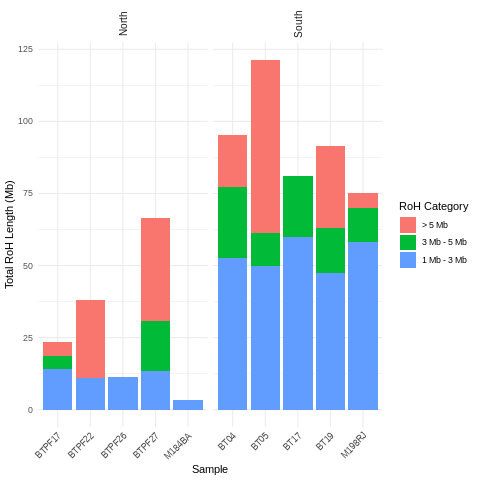

In [34]:
%%R

# Read data with read_delim() for better control over input file parsing
roh <- read_delim("drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/bradypus.roh.with.population.txt",
                  delim = "\t", skip = 1, col_names = c("Sample", "Chromosome", "RoH_length", "Population"))

# Create RoH length categories
roh_categories <- roh %>%
  mutate(RoH_category = case_when(
      RoH_length >= 1000000 & RoH_length < 3000000 ~ "1 Mb - 3 Mb",
      RoH_length >= 3000000 & RoH_length < 5000000 ~ "3 Mb - 5 Mb",
      RoH_length >= 5000000 ~ "> 5 Mb",
      TRUE ~ NA_character_)) %>% # Assign NA to lengths < 1 Mb
  mutate(RoH_category = factor(RoH_category, levels = c("> 5 Mb", "3 Mb - 5 Mb", "1 Mb - 3 Mb"))) %>%
  filter(!is.na(RoH_category)) # Remove rows where RoH_category is NA

# Summing RoH_length by Sample, RoH_category, and Population
summed_roh <- roh_categories %>%
  group_by(Sample, RoH_category, Population) %>%
  summarise(total_RoH_length = sum(RoH_length), .groups = "drop")  # Sum the RoH_length for each group

print(summed_roh)

# Create the stacked bar plot
stacked_barplot <- summed_roh %>%
  ggplot(aes(x = Sample, y = total_RoH_length/1000000, fill = RoH_category)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ Population, nrow =1, scales = "free_x") +  # Facet by Population
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(angle = 90, size = 10)) +
  scale_y_continuous(labels = scales::comma) +
  labs(x = "Sample", y = "Total RoH Length (Mb)", fill = "RoH Category")

# Print the plot
print(stacked_barplot)
ggsave("drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/stacked_barplot.png", stacked_barplot, width = 8, height = 6, dpi = 300)

 > 🦥❓ Compare o nível de consanguinidade entre as preguiças de coleira do Norte e do Sul. O que significa a presença de ROHs com comprimento acima de 5 Mb?

#### b) Plot FROH
Agora vamos estimar o coeficiente de consanguinidade genômica, FROH, para cada indivíduo. Essa métrica quantifica a proporção do genoma autossômico que é autozigótica. Ela é calculada como:

$$
F_{ROH} = \frac{\text{Soma do comprimento das regiões ROH }(S_{ROH})}{\text{Comprimento total do genoma analisado}}
$$

Para esta análise, definiremos o comprimento mínimo de ROH como 1 Mb. Observe que o tamanho do genoma (196.509.262 pb) considerado corresponde apenas à parte incluída nesta análise tutorial, que é limitada a dois cromossomos devido a restrições de tempo e recursos.

Rows: 1681 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): Sample, Chromosome, Population
dbl (1): RoH_length

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


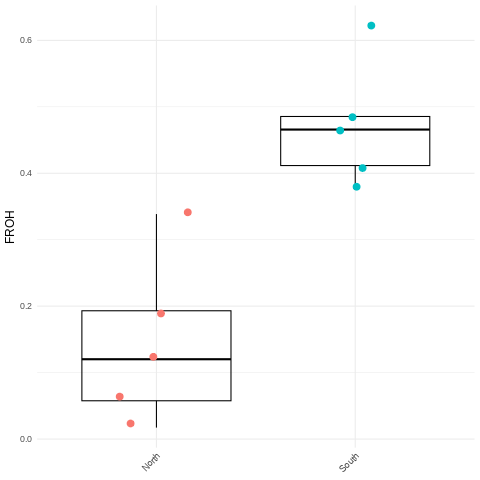

In [35]:
%%R
#Estimate FROH

# Read data with read_delim() for better control over input file parsing
roh <- read_delim("drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/bradypus.roh.with.population.txt", delim = "\t", skip = 1, col_names = c("Sample", "Chromosome", "RoH_length", "Population"))

# Create RoH length categories
roh_categories <- roh %>%
  mutate(RoH_category = case_when(
      RoH_length >= 1000000 & RoH_length < 3000000 ~ "1 Mb - 3 Mb",
      RoH_length >= 3000000 & RoH_length < 5000000 ~ "3 Mb - 5 Mb",
      RoH_length >= 5000000 ~ "> 5 Mb",
      TRUE ~ NA_character_)) %>% # Assign NA to lengths < 1 Mb
  mutate(RoH_category = factor(RoH_category, levels = c("> 5 Mb", "3 Mb - 5 Mb", "1 Mb - 3 Mb"))) %>%
  filter(!is.na(RoH_category)) # Remove rows where RoH_category is NA

# Define the total genome length in the analysis (in our case, we included only two chromosomes)
total_chromosome_length <- 196509262

# Calculate FROH for each sample
frohs <- roh_categories %>%
  filter(RoH_length > 1000000) %>%  # Only include RoH_length > 1 Mb
  group_by(Sample) %>%
  summarise(total_RoH_above_1Mb = sum(RoH_length)) %>%
  mutate(FROH = total_RoH_above_1Mb / total_chromosome_length)  # Calculate FROH

# Join it with the original roh_categories to retain Population information
frohs_with_population <- frohs %>%
  left_join(roh_categories %>% select(Sample, Population) %>% distinct(), by = "Sample")

# Reorder the Sample factor by Population
frohs_with_population$Sample <- factor(frohs_with_population$Sample,
                                       levels = unique(frohs_with_population$Sample[order(frohs_with_population$Population)]))

# Create a boxplot per population with individual dots per sample
boxplot_froh <- frohs_with_population %>%
  ggplot(aes(x = Population, y = FROH, color = Population)) +
  geom_boxplot(outlier.shape = NA, fill = "transparent", color = "black") +
  geom_jitter(aes(color = Population), size = 3, width = 0.2) +
  theme_minimal() +  # Minimal theme for clean visualization
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title.x = element_blank(),
    axis.title.y = element_text(size = 12),
    legend.position = "none" ) +
  labs(y = "FROH", x = "Population")

# Print the plot
print(boxplot_froh)
ggsave("drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/boxplot_froh.png", boxplot_froh, width = 8, height = 6, dpi = 300)

> 🦥❓Como os níveis de consanguinidade se relacionam com os níveis de heterozigosidade das populações?


#### c) Plote o número total de ROH (NROH) e a soma do comprimento total de ROH (SROH)

Duas das estatísticas mais básicas que podemos obter a partir dessa análise são o número total de ROH (NROH) e a soma do comprimento total de ROH (SROH). Você pode usar o seguinte script R para estimar esses valores e traçar os resultados.

Rows: 1681 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): Sample, Chromosome, Population
dbl (1): RoH_length

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggrepel_0.9.8.tar.gz'
Content type 'application/x-gzip' length 151726 bytes (148 KB)
downloaded 148 KB


The downloaded source packages are in
	‘/tmp/Rtmptvafvn/downloaded_packages’


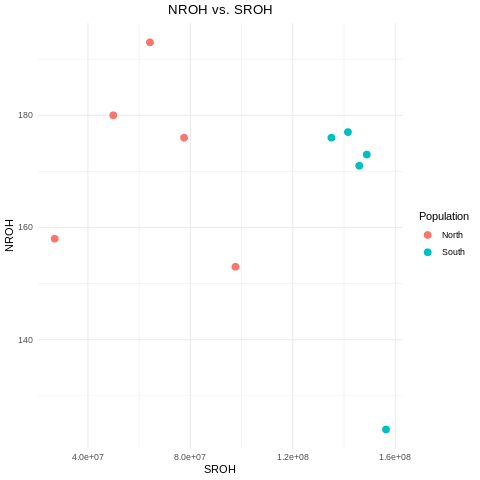

In [36]:
%%R

# Load libraries and read data
library(tidyverse)
install.packages("ggrepel")
library(ggrepel)

# Read data with read_delim() for better control over input file parsing
roh <- read_delim("drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/bradypus.roh.with.population.txt", delim = "\t", skip = 1, col_names = c("Sample", "Chromosome", "RoH_length", "Population"))

# Compute NROH and SROH
nroh <- roh %>%
  group_by(Sample) %>%
  summarize(NROH = n())

sroh <- roh %>%
  group_by(Sample) %>%
  summarize(SROH = sum(RoH_length))

# Combine population information
data <- inner_join(nroh, sroh, by = "Sample") %>%
  inner_join(roh %>% select(Sample, Population) %>% distinct(), by = "Sample")

# Inspect the resulting dataset to ensure it is correct
head(data)

# Create the plot using the preprocessed dataset
snroh_plot <- data %>%
  ggplot(aes(x = SROH, y = NROH, color = Population)) +
  geom_point(size = 3) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5)) +
  labs(title = "NROH vs. SROH", color = "Population")

# Print the plot
print(snroh_plot)
ggsave("drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/sroh_nroh.png", snroh_plot, width = 8, height = 6, dpi = 300)

> 🦥❓ Como a comparação entre o comprimento total das sequências ROH (SROH) e o número total de ROHs (NROH) pode fornecer informações sobre a história demográfica das preguiças de coleira do Norte e do Sul? 💡 Dica: Este [artigo](https://drive.google.com/file/d/1VPbgsvdcFHzU7tLRbjR99shMq8xo06QE/view?usp=sharing) pode ajudá-lo a encontrar uma explicação.

#### d) Converta o comprimento do ROH em tempo em gerações

Agora vamos converter o comprimento do ROH em tempo em gerações usando a fórmula abaixo:

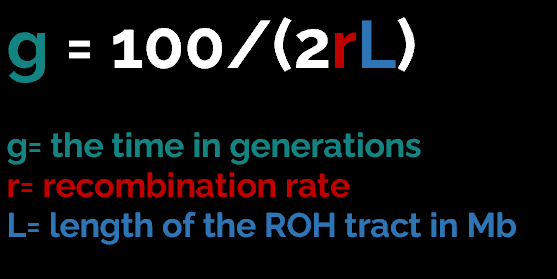

Utilizaremos a taxa média de recombinação em mamíferos de 1 cM/Mb.

Rows: 1681 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): Sample, Chromosome, Population
dbl (1): RoH_length

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Sample, generation_interval, and
  Population.
ℹ Output is grouped by Sample and generation_interval.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Sample, generation_interval, Population))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.


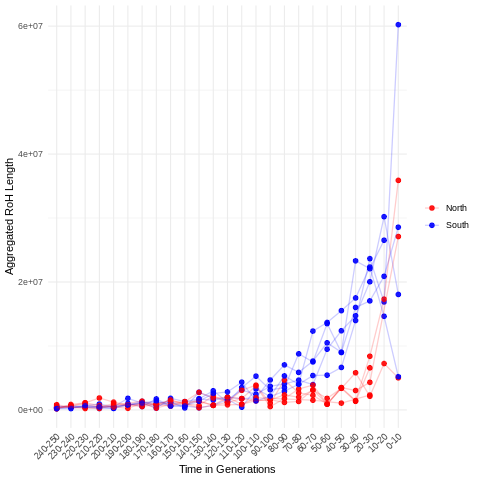

In [40]:
%%R

# Load repr package to control plot size
if(!require(repr)) install.packages("repr", repos='http://cran.us.r-project.org')
library(repr)

# Set the plot size (width x height in inches)
options(repr.plot.width=15, repr.plot.height=6)

# Read data with read_delim() for better control over input file parsing
roh <- read_delim("drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/bradypus.roh.with.population.txt",
                  delim = "\t", skip = 1,
                  col_names = c("Sample", "Chromosome", "RoH_length", "Population"))

roh <- roh %>%
  mutate(time_in_generations = 100 / (2 * 1 * (RoH_length / 1000000))) # Length in Mb

# Create intervals of 5 generations
roh$generation_interval <- cut(roh$time_in_generations,
        breaks = seq(0, max(roh$time_in_generations, na.rm = TRUE) + 10, by = 10), right = FALSE,
        labels = paste(seq(0, max(roh$time_in_generations, na.rm = TRUE), by = 10),
                       seq(10, max(roh$time_in_generations, na.rm = TRUE) + 10, by = 10), sep = "-"))

# Filter for RoH_length > 200 kb and summarize
summarized_data <- roh %>%
  filter(RoH_length > 200000) %>%
  group_by(Sample, generation_interval, Population) %>%
  summarise(total_RoH_length = sum(RoH_length, na.rm = TRUE)) %>%
  arrange(generation_interval)

# Define sample colors including AtlanticForest
summarized_data <- summarized_data %>%
  mutate(sample_color = ifelse(startsWith(Population, "North"), "North",
                               ifelse(startsWith(Population, "South"), "South"))) %>%
  mutate(generation_interval = factor(generation_interval, levels = rev(levels(generation_interval))))

# Plot a dot-and-line plot
time_in_gen_plot <- ggplot(summarized_data, aes(x = generation_interval, y = total_RoH_length,
                                                 color = sample_color, group = Sample)) +
  geom_point(size = 2, alpha = 0.9) +
  geom_line(aes(group = Sample), size = 0.6, alpha = 0.2) +
  labs(x = "Time in Generations", y = "Aggregated RoH Length") +
  scale_color_manual(values = c("North" = "red", "South" = "blue")) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.title = element_blank())

# Print and save the plot
print(time_in_gen_plot)
ggsave("drive/MyDrive/PopGen_UFMG_2026/analyses/05_ROH/time_in_gen_plot.png",
       time_in_gen_plot, width = 15, height = 6, dpi = 300)


> 🦥❓ Há quantas gerações os níveis de consanguinidade começaram a aumentar nas preguiças de coleira do Norte e do Sul? Considerando que o tempo de geração deles é de 5 anos, há quantos anos esse aumento ocorreu?